In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
file_path = r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day6_analysis.csv"
df = pd.read_csv(file_path)

In [3]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

numerical_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [4]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"{col} Outliers: {outliers.shape[0]}")

tenure Outliers: 0
MonthlyCharges Outliers: 0
TotalCharges Outliers: 0


In [5]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        np.where(
            df[col] < lower_bound,
            lower_bound,
            df[col]
        )
    )

In [ ]:
#The TotalCharges column originally contained blank string values (" ").
#During datatype conversion to numeric, those blanks became NaN, which is why df_minmax_scaled.isnull().sum() still shows 11 null values.
#Feature scaling does NOT remove null values automatically.

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

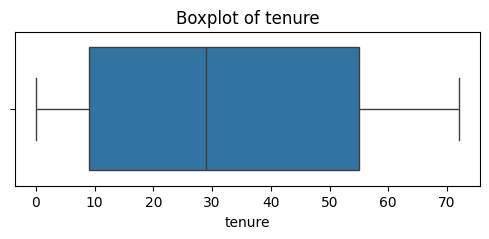

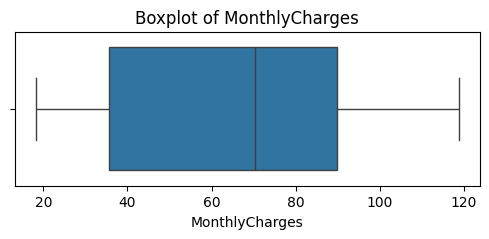

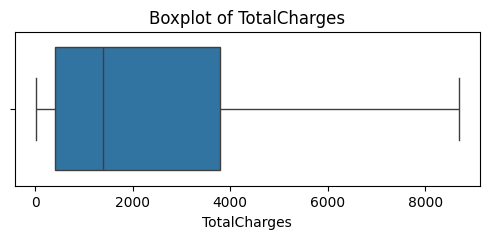

In [13]:
for col in numerical_cols:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

In [14]:
standard_scaler = StandardScaler()

df_standard_scaled = df.copy()

df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(
    df_standard_scaled[numerical_cols]
)

df_standard_scaled.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,-1.277445,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,-1.160323,-0.994242,No
1,5575-GNVDE,Male,0,No,No,0.066327,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,-0.259629,-0.173244,No
2,3668-QPYBK,Male,0,No,No,-1.236724,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.959674,Yes
3,7795-CFOCW,Male,0,No,No,0.514251,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.746535,-0.194766,No
4,9237-HQITU,Female,0,No,No,-1.236724,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.940470,Yes


In [15]:
minmax_scaler = MinMaxScaler()

df_minmax_scaled = df.copy()

df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(
    df_minmax_scaled[numerical_cols]
)

df_minmax_scaled.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,0.013889,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.001275,No
1,5575-GNVDE,Male,0,No,No,0.472222,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,0.385075,0.215867,No
2,3668-QPYBK,Male,0,No,No,0.027778,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.010310,Yes
3,7795-CFOCW,Male,0,No,No,0.625000,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.210241,No
4,9237-HQITU,Female,0,No,No,0.027778,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.015330,Yes


In [16]:
X = df_minmax_scaled.drop('Churn', axis=1)

y = df_minmax_scaled['Churn']

print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 20)
(1409, 20)
(5634,)
(1409,)


In [18]:
df_minmax_scaled.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df_minmax_scaled.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [ ]:
#CLEANED DAY 09 DATASET
df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day9_cleaned.csv",
    index=False
)

In [ ]:
#PROCESSED DAY 09 DATASET
df_minmax_scaled.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day9_processed.csv",
    index=False
)

In [22]:
print("Total Customers :", df.shape[0])

print("Total Columns :", df.shape[1])

print("Churn Rate :")
print(df['Churn'].value_counts(normalize=True) * 100)

print("Average Monthly Charges :")
print(df['MonthlyCharges'].mean())

print("Average Tenure :")
print(df['tenure'].mean())

Total Customers : 7043
Total Columns : 21
Churn Rate :
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
Average Monthly Charges :
64.76169246059918
Average Tenure :
32.37114865824223


In [23]:
#DATASET EXPORT
X_train.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\X_train.csv",
    index=False
)

X_test.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\X_test.csv",
    index=False
)

y_train.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\y_train.csv",
    index=False
)

y_test.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\y_test.csv",
    index=False
)